# RnD-3: автоматический выбор `max_iter` в процедуре рерандомизации

Этот ноутбук демонстрирует простую вероятностную модель для выбора числа итераций рерандомизации
в текущей реализации алгоритма, где итерация считается успешной, если по **всем** признакам
выполняется условие `p_value > alpha`.

В ноутбуке рассматриваются два подхода:

1. **Формульный подход** — заранее вычислить `max_iter` так, чтобы с вероятностью не ниже $\gamma$
   получить хотя бы одну успешную итерацию.
2. **Early-stop** — завершать алгоритм после накопления `r` успешных итераций и затем выбирать
   лучшую из них по текущему агрегированному правилу.

Дополнительно показано, как вместо фактического числа признаков `k` использовать
**эффективное число тестов** `k_eff`, вычисляемое по корреляционной матрице признаков.


## Содержательная постановка

Пусть:

- на одной итерации проверяется `k` признаков;
- по каждому признаку выполняется статистический тест;
- итерация считается успешной, если **все** тесты дают `p_value > alpha`.

Если принять упрощающее допущение о независимости тестов, то вероятность успеха одной итерации:
$$
q = (1-\alpha)^k.
$$

Тогда вероятность получить хотя бы одну успешную итерацию за `N` попыток:
$$
P(\text{хотя бы одна успешная}) = 1 - (1-q)^N.
$$

Отсюда минимальное число итераций, обеспечивающее вероятность успеха не ниже `gamma`:
$$
N \ge \frac{\log(1-\gamma)}{\log(1-q)}.
$$

Если же используется early-stop после `r` успешных итераций, то в модели независимых
одинаково распределённых испытаний ожидаемое число итераций:
$$
\mathbb{{E}}[T_r] = \frac{r}{q}.
$$

Далее эти формулы переводятся в код и сравниваются на сетке значений числа признаков.


In [25]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## Функции для вычисления `max_iter` и числа итераций при early-stop

In [26]:
def success_prob_from_k(k: float, alpha: float = 0.05) -> float:
    """Аппроксимация вероятности успеха одной итерации через число тестов k."""
    return (1 - alpha) ** k

def max_iter_from_success_prob(q: float, gamma: float = 0.95) -> int:
    """Минимальное число итераций, обеспечивающее хотя бы один успех с вероятностью >= gamma."""
    if not (0 < q < 1):
        if q >= 1:
            return 1
        raise ValueError("q должно лежать в интервале (0, 1).")
    return math.ceil(math.log(1 - gamma) / math.log(1 - q))

def max_iter_from_k(k: float, alpha: float = 0.05, gamma: float = 0.95) -> int:
    """Число итераций через фактическое число тестов k."""
    q = success_prob_from_k(k=k, alpha=alpha)
    return max_iter_from_success_prob(q=q, gamma=gamma)

def expected_iters_early_stop(q: float, r: int = 3) -> float:
    """Ожидаемое число итераций до накопления r успешных итераций."""
    if not (0 < q <= 1):
        raise ValueError("q должно лежать в интервале (0, 1].")
    return r / q

def expected_iters_early_stop_from_k(k: float, alpha: float = 0.05, r: int = 3) -> float:
    q = success_prob_from_k(k=k, alpha=alpha)
    return expected_iters_early_stop(q=q, r=r)


## Эффективное число тестов

Если признаки коррелированы, использовать фактическое число тестов `k` может быть слишком консервативно.
Тогда можно заменить его на **эффективное число тестов** `k_eff`.

Ниже реализована простая собственно-значная аппроксимация в духе Li–Ji:

1. строится корреляционная матрица `R`,
2. считаются её собственные значения $\lambda_1, ..., \lambda_k$,
3. затем используется оценка
$$
k_{{eff}} = k - \sum_{{i=1}}^k I(\lambda_i > 1)(\lambda_i - 1).
$$

Интуитивно: если некоторые собственные значения существенно больше 1, это означает,
что часть тестов несёт дублирующую информацию, и реальное число почти независимых
проверок меньше фактического числа признаков.


In [27]:
def effective_num_tests_li_ji(corr: np.ndarray) -> float:
    """Оценка эффективного числа тестов по собственным значениям корреляционной матрицы."""
    vals = np.linalg.eigvalsh(corr)
    vals = np.real(vals)
    keff = len(vals) - np.sum(np.where(vals > 1, vals - 1, 0.0))
    return float(keff)

def max_iter_from_keff(keff: float, alpha: float = 0.05, gamma: float = 0.95) -> int:
    q = success_prob_from_k(k=keff, alpha=alpha)
    return max_iter_from_success_prob(q=q, gamma=gamma)

def expected_iters_early_stop_from_keff(keff: float, alpha: float = 0.05, r: int = 3) -> float:
    q = success_prob_from_k(k=keff, alpha=alpha)
    return expected_iters_early_stop(q=q, r=r)

def ar1_corr_matrix(k: int, rho: float) -> np.ndarray:
    idx = np.arange(k)
    return rho ** np.abs(np.subtract.outer(idx, idx))


## Демонстрация 1. Таблица по сетке числа признаков

In [28]:
alpha = 0.05
gamma = 0.95
r = 1

k_grid = list(range(5, 105, 5))

rows = []
for k in k_grid:
    q = success_prob_from_k(k, alpha=alpha)
    rows.append({
        "k": k,
        "q=(1-alpha)^k": q,
        "max_iter_formula": max_iter_from_k(k, alpha=alpha, gamma=gamma),
        "expected_iters_early_stop_r3": expected_iters_early_stop_from_k(k, alpha=alpha, r=r),
    })

grid_df = pd.DataFrame(rows)
grid_df.head(10)


,k,q=(1-alpha)^k,max_iter_formula,expected_iters_early_stop_r3
0,5,0.773781,3,1.292355
1,10,0.598737,4,1.670183
2,15,0.463291,5,2.158470
3,20,0.358486,7,2.789510
4,25,0.277390,10,3.605038
5,30,0.214639,13,4.658991
6,35,0.166083,17,6.021072
7,40,0.128512,22,7.781365
8,45,0.099440,29,10.056289
9,50,0.076945,38,12.996300


In [29]:
grid_df.tail(10)


,k,q=(1-alpha)^k,max_iter_formula,expected_iters_early_stop_r3
10,55,0.059539,49,16.795839
11,60,0.046070,64,21.706194
12,65,0.035648,83,28.052118
13,70,0.027584,108,36.253307
14,75,0.021344,139,46.852158
15,80,0.016515,180,60.549642
16,85,0.012779,233,78.251658
17,90,0.009888,302,101.128956
18,95,0.007651,391,130.694556
19,100,0.005921,505,168.903820


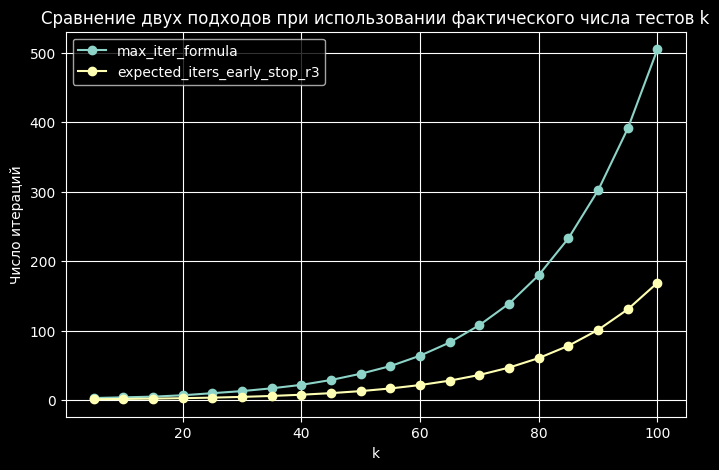

In [30]:
ax = grid_df.plot(x="k", y=["max_iter_formula", "expected_iters_early_stop_r3"], marker="o")
ax.set_ylabel("Число итераций")
ax.set_title("Сравнение двух подходов при использовании фактического числа тестов k")
plt.show()


Интерпретация:

- `max_iter_formula` — это жёсткая верхняя граница числа попыток, которая обеспечивает вероятность
  не ниже `gamma` получить хотя бы одну успешную итерацию;
- `expected_iters_early_stop_r3` — это ожидаемое число итераций до накопления `r=3`
  успешных итераций.

При росте числа признаков обе оценки быстро растут, так как успех одной итерации становится всё менее вероятным.


## Демонстрация 2. Роль корреляции и переход от `k` к `k_eff`

In [31]:
rho_values = [0.0, 0.3, 0.6, 0.8]
k_demo = 40

rows = []
for rho in rho_values:
    corr = ar1_corr_matrix(k=k_demo, rho=rho)
    keff = effective_num_tests_li_ji(corr)
    rows.append({
        "k": k_demo,
        "rho": rho,
        "k_eff": keff,
        "max_iter_by_k": max_iter_from_k(k_demo, alpha=alpha, gamma=gamma),
        "max_iter_by_k_eff": max_iter_from_keff(keff, alpha=alpha, gamma=gamma),
        "early_stop_by_k": expected_iters_early_stop_from_k(k_demo, alpha=alpha, r=r),
        "early_stop_by_k_eff": expected_iters_early_stop_from_keff(keff, alpha=alpha, r=r),
    })

corr_df = pd.DataFrame(rows)
corr_df


,k,rho,k_eff,max_iter_by_k,max_iter_by_k_eff,early_stop_by_k,early_stop_by_k_eff
0,40,0.0,40.000000,22,22,7.781365,7.781365
1,40,0.3,32.350451,22,15,7.781365,5.255952
2,40,0.6,23.838191,22,9,7.781365,3.396479
3,40,0.8,16.726309,22,6,7.781365,2.358315


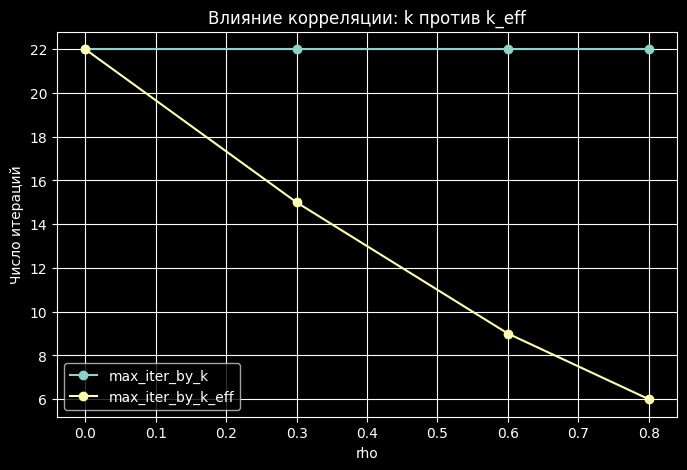

In [32]:
ax = corr_df.plot(x="rho", y=["max_iter_by_k", "max_iter_by_k_eff"], marker="o")
ax.set_ylabel("Число итераций")
ax.set_title("Влияние корреляции: k против k_eff")
plt.show()


Интерпретация:

- при $\rho = 0$ эффективное число тестов почти совпадает с `k`;
- при росте корреляции `k_eff` уменьшается;
- следовательно, оценка числа итераций через `k_eff` становится менее консервативной,
  чем оценка через фактическое число тестов `k`.

Это и есть основное содержательное преимущество использования `k_eff`.


## Демонстрация 3. Универсальная функция выбора числа итераций

In [33]:
def choose_max_iter(
    alpha: float = 0.05,
    gamma: float = 0.95,
    k: int | None = None,
    corr: np.ndarray | None = None,
    mode: str = "k",
):
    """
    Универсальная функция выбора max_iter.

    mode='k'     -> используется фактическое число тестов k
    mode='k_eff' -> используется эффективное число тестов, вычисленное по corr
    """
    if mode == "k":
        if k is None:
            raise ValueError("Для mode='k' необходимо передать k.")
        return {
            "mode": "k",
            "k_used": float(k),
            "success_prob": success_prob_from_k(k=k, alpha=alpha),
            "max_iter": max_iter_from_k(k=k, alpha=alpha, gamma=gamma),
        }
    elif mode == "k_eff":
        if corr is None:
            raise ValueError("Для mode='k_eff' необходимо передать корреляционную матрицу corr.")
        keff = effective_num_tests_li_ji(corr)
        return {
            "mode": "k_eff",
            "k_used": float(keff),
            "success_prob": success_prob_from_k(k=keff, alpha=alpha),
            "max_iter": max_iter_from_keff(keff=keff, alpha=alpha, gamma=gamma),
        }
    else:
        raise ValueError("mode должен быть 'k' или 'k_eff'.")


In [34]:
choose_max_iter(alpha=0.05, gamma=0.95, k=30, mode="k")


{'mode': 'k',
 'k_used': 30.0,
 'success_prob': 0.21463876394293727,
 'max_iter': 13}

In [35]:
corr = ar1_corr_matrix(k=30, rho=0.7)
choose_max_iter(alpha=0.05, gamma=0.95, corr=corr, mode="k_eff")


{'mode': 'k_eff',
 'k_used': 15.459808246959096,
 'success_prob': 0.45249231673098017,
 'max_iter': 5}

## Дополнительная функция для early-stop

In [36]:
def choose_expected_iters_early_stop(
    alpha: float = 0.05,
    r: int = 3,
    k: int | None = None,
    corr: np.ndarray | None = None,
    mode: str = "k",
):
    if mode == "k":
        if k is None:
            raise ValueError("Для mode='k' необходимо передать k.")
        q = success_prob_from_k(k=k, alpha=alpha)
        return {
            "mode": "k",
            "k_used": float(k),
            "success_prob": q,
            "expected_iters": expected_iters_early_stop(q=q, r=r),
        }
    elif mode == "k_eff":
        if corr is None:
            raise ValueError("Для mode='k_eff' необходимо передать корреляционную матрицу corr.")
        keff = effective_num_tests_li_ji(corr)
        q = success_prob_from_k(k=keff, alpha=alpha)
        return {
            "mode": "k_eff",
            "k_used": float(keff),
            "success_prob": q,
            "expected_iters": expected_iters_early_stop(q=q, r=r),
        }
    else:
        raise ValueError("mode должен быть 'k' или 'k_eff'.")


In [37]:
choose_expected_iters_early_stop(alpha=0.05, r=3, k=30, mode="k")


{'mode': 'k',
 'k_used': 30.0,
 'success_prob': 0.21463876394293727,
 'expected_iters': 13.976972029141782}

In [38]:
choose_expected_iters_early_stop(alpha=0.05, r=3, corr=corr, mode="k_eff")


{'mode': 'k_eff',
 'k_used': 15.459808246959096,
 'success_prob': 0.45249231673098017,
 'expected_iters': 6.629946827989097}

## Краткое резюме

1. В текущей реализации max_iter можно выбирать по формуле через вероятность успеха одной итерации.
2. Базовая формула использует фактическое число тестов k и даёт консервативную оценку.
3. Более содержательный вариант — заменить k на эффективное число тестов k_eff.
4. Early-stop математически корректен и естественно описывается через отрицательно-биномиальную модель.
5. Если признаки сильно коррелированы, использование k_eff может существенно уменьшить требуемое число итераций.